# Линейная алгебра, математический анализ

Решения оформлены в Markdown + LaTeX (рендер через MathJax), вычисления и проверки — в **SymPy** (символьно) и **NumPy** (численно).

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

sp.init_printing(use_latex='mathjax')   # рендер формул SymPy через MathJax (LaTeX)

# Часть 1. Линейная алгебра

## Задача 1

Даны матрицы
$$
A=\begin{pmatrix}2&-4\\3&5\\-1&0\end{pmatrix},\quad
B=\begin{pmatrix}1&2&7\\-3&-4&0\\5&2&1\end{pmatrix},\quad
C=\begin{pmatrix}6&-3&9\\4&-5&2\\8&1&5\end{pmatrix}.
$$
Требуется вычислить $D=A^\top C-2A^\top B^\top$.

**Решение.** Транспонируем $A$:
$$A^\top=\begin{pmatrix}2&3&-1\\-4&5&0\end{pmatrix}.$$

Первое слагаемое $A^\top C$ (размер $2\times3$):
$$
A^\top C=\begin{pmatrix}2&3&-1\\-4&5&0\end{pmatrix}
\begin{pmatrix}6&-3&9\\4&-5&2\\8&1&5\end{pmatrix}
=\begin{pmatrix}16&-22&19\\-4&-13&-26\end{pmatrix}.
$$

Транспонируем $B$ и считаем $A^\top B^\top$:
$$
B^\top=\begin{pmatrix}1&-3&5\\2&-4&2\\7&0&1\end{pmatrix},\qquad
A^\top B^\top=\begin{pmatrix}1&-18&15\\6&-8&-10\end{pmatrix}.
$$

Отсюда
$$
D=A^\top C-2A^\top B^\top
=\begin{pmatrix}16&-22&19\\-4&-13&-26\end{pmatrix}
-2\begin{pmatrix}1&-18&15\\6&-8&-10\end{pmatrix}
=\begin{pmatrix}14&14&-11\\-16&3&-6\end{pmatrix}.
$$

In [2]:
A = sp.Matrix([[2, -4], [3, 5], [-1, 0]])
B = sp.Matrix([[1, 2, 7], [-3, -4, 0], [5, 2, 1]])
C = sp.Matrix([[6, -3, 9], [4, -5, 2], [8, 1, 5]])

D = A.T * C - 2 * A.T * B.T
D

⎡14   14  -11⎤
⎢            ⎥
⎣-16  3   -6 ⎦

## Задача 2

$$
3\begin{pmatrix}x&2&3\\-1&y&4\end{pmatrix}
+2\begin{pmatrix}1&2&-5\\2&-6&z\end{pmatrix}
=\begin{pmatrix}8&v&-1\\1&6&4\end{pmatrix}.
$$

**Решение.** Сложив левую часть поэлементно и приравняв к правой, получаем уравнения по позициям:
$$
\begin{aligned}
(1,1):\;& 3x+2=8 &&\Rightarrow\; x=2,\\
(1,2):\;& 6+4=v   &&\Rightarrow\; v=10,\\
(2,2):\;& 3y-12=6 &&\Rightarrow\; y=6,\\
(2,3):\;& 12+2z=4 &&\Rightarrow\; z=-4.
\end{aligned}
$$
Позиции $(1,3):\,9-10=-1$ и $(2,1):\,-3+4=1$ не содержат неизвестных и выполняются тождественно — система совместна.

**Ответ:** $x=2,\ y=6,\ z=-4,\ v=10$.

In [3]:
x, y, z, v = sp.symbols('x y z v')
L = 3 * sp.Matrix([[x, 2, 3], [-1, y, 4]]) + 2 * sp.Matrix([[1, 2, -5], [2, -6, z]])
R = sp.Matrix([[8, v, -1], [1, 6, 4]])

sp.solve(list(L - R), [x, y, z, v], dict=True)

[{v: 10, x: 2, y: 6, z: -4}]

## Задача 3

$$A=\begin{pmatrix}1&2&3\\3&6&p\\5&10&q\end{pmatrix}.$$
При каких $p,q$ ранг равен $1$?

**Решение.** $\operatorname{rank}A=1$ означает, что все строки пропорциональны одной ненулевой. Формально это равносильно тому, что **все миноры 2-го порядка обращаются в ноль** (первая строка $(1,2,3)$ ненулевая, поэтому ранг не меньше $1$). Достаточно взять миноры, содержащие неизвестные:
$$
\det\begin{pmatrix}1&3\\3&p\end{pmatrix}=p-9=0,\qquad
\det\begin{pmatrix}1&3\\5&q\end{pmatrix}=q-15=0,
$$
откуда $p=9,\ q=15$. При этих значениях вторая и третья строки равны $3\cdot(1,2,3)$ и $5\cdot(1,2,3)$ — все миноры зануляются, значит $\operatorname{rank}A=1$.

**Ответ:** $p=9,\ q=15$.

In [4]:
import itertools

p, q = sp.symbols('p q')
A3 = sp.Matrix([[1, 2, 3], [3, 6, p], [5, 10, q]])

# rank = 1  <=>  все миноры 2-го порядка равны нулю.
# Берём определители всех подматриц 2x2 и отбрасываем тождественные нули.
minors = [A3[list(rows), list(cols)].det()
          for rows in itertools.combinations(range(3), 2)
          for cols in itertools.combinations(range(3), 2)]
conditions = [m for m in minors if m != 0]

sol = sp.solve(conditions, [p, q], dict=True)
conditions, sol

([p - 9, 2⋅p - 18, q - 15, 2⋅q - 30, -5⋅p + 3⋅q, -10⋅p + 6⋅q], [{p: 9, q: 15}])

## Задача 4

$a_1=(2,-5)^\top,\ a_2=(-1,3)^\top,\ x=(1,-4)^\top.$ Базис $B=[\,a_1\ a_2\,]$.

**Линейная независимость.** Матрица перехода из координат базиса $B$ в стандартные:
$$P_B=\begin{pmatrix}2&-1\\-5&3\end{pmatrix},\qquad \det P_B=2\cdot3-(-1)(-5)=1\neq0,$$
значит $a_1,a_2$ линейно независимы и образуют базис.

**(a)** Координаты $x$ в базисе $B$: $[x]_B=P_B^{-1}x$. Так как $\det P_B=1$,
$$P_B^{-1}=\begin{pmatrix}3&1\\5&2\end{pmatrix},\qquad
[x]_B=\begin{pmatrix}3&1\\5&2\end{pmatrix}\begin{pmatrix}1\\-4\end{pmatrix}=\begin{pmatrix}-1\\-3\end{pmatrix}.$$
Проверка: $-1\cdot a_1-3\cdot a_2=(-2,5)^\top+(3,-9)^\top=(1,-4)^\top=x.$

**(b)** Если $[y]_B=(1,1)^\top$, то в стандартном базисе
$$y=P_B[y]_B=\begin{pmatrix}2&-1\\-5&3\end{pmatrix}\begin{pmatrix}1\\1\end{pmatrix}=\begin{pmatrix}1\\-2\end{pmatrix}.$$

In [5]:
P = sp.Matrix([[2, -1], [-5, 3]])      # столбцы — векторы a1, a2
xv = sp.Matrix([1, -4])

det = P.det()                          # != 0  =>  a1, a2 линейно независимы
x_B = P.inv() * xv                     # (a) координаты x в базисе B
y_std = P * sp.Matrix([1, 1])          # (b) вектор y в стандартном базисе

check = P * x_B                        # проверка (a): должно получиться x = (1, -4)
det, x_B, y_std, check

⎛   ⎡-1⎤  ⎡1 ⎤  ⎡1 ⎤⎞
⎜1, ⎢  ⎥, ⎢  ⎥, ⎢  ⎥⎟
⎝   ⎣-3⎦  ⎣-2⎦  ⎣-4⎦⎠

## Задача 5. Малоранговая аппроксимация (SVD)

Для случайной матрицы $A\in\mathbb{R}^{n\times n}$ через сингулярное разложение $A=U\Sigma V^\top$ строим приближение ранга $r$:
$$\tilde A_r=U_{:,\,:r}\,\Sigma_{:r,:r}\,V^\top_{:r,\,:},$$
и считаем ошибку в норме Фробениуса $E(r)=\|A-\tilde A_r\|_F$. По теореме Эккарта–Янга усечение SVD даёт наилучшее приближение ранга $r$, а сама ошибка равна $E(r)=\sqrt{\sum_{i>r}\sigma_i^2}$ — корню из суммы квадратов отброшенных сингулярных чисел. Поэтому кривая монотонно убывает и обращается в ноль при $r=n$.

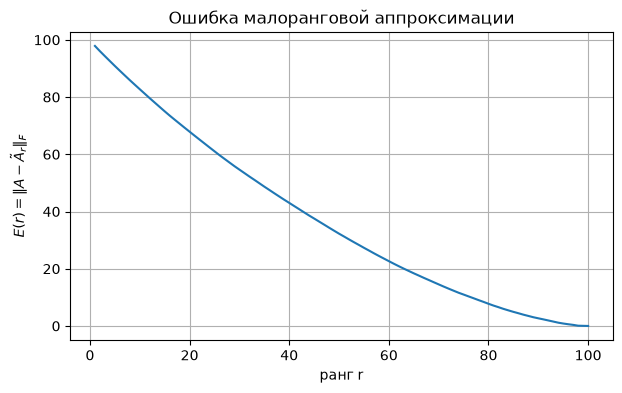

In [6]:
n = 100
rng = np.random.default_rng(0)
A = rng.standard_normal((n, n))

U, S, Vt = np.linalg.svd(A)            # A = U @ diag(S) @ Vt

ranks = range(1, n + 1)
errors = [np.linalg.norm(A - U[:, :r] @ np.diag(S[:r]) @ Vt[:r, :], 'fro')
          for r in ranks]

plt.figure(figsize=(7, 4))
plt.plot(list(ranks), errors)
plt.xlabel('ранг r')
plt.ylabel(r'$E(r)=\|A-\tilde A_r\|_F$')
plt.title('Ошибка малоранговой аппроксимации')
plt.grid(True)
plt.show()

# Часть 2. Начала мат.анализа и оптимизации

## Задача 1. Градиент и критические точки

$$f(x)=x_1^3-2x_1x_2+x_2^2-3x_1-2x_2,\qquad x\in\mathbb{R}^2.$$

**Градиент.**
$$\nabla f=\begin{pmatrix}\partial f/\partial x_1\\[2pt]\partial f/\partial x_2\end{pmatrix}
=\begin{pmatrix}3x_1^2-2x_2-3\\-2x_1+2x_2-2\end{pmatrix}.$$

**Критические точки** ($\nabla f=0$). Из второго уравнения $x_2=x_1+1$; подставляя в первое,
$$3x_1^2-2(x_1+1)-3=3x_1^2-2x_1-5=0\;\Rightarrow\; x_1=\tfrac{5}{3}\ \text{или}\ x_1=-1,$$
откуда две точки:
$$x_c^{(1)}=\left(\tfrac{5}{3},\ \tfrac{8}{3}\right),\qquad x_c^{(2)}=(-1,\ 0).$$

**Характер** (гессиан $H=\begin{pmatrix}6x_1&-2\\-2&2\end{pmatrix}$, $\det H=12x_1-4$): в $(5/3,8/3)$ имеем $\det H=16>0,\ 6x_1>0$ — локальный минимум; в $(-1,0)$ имеем $\det H=-16<0$ — седловая точка.

In [7]:
x1, x2 = sp.symbols('x1 x2', real=True)
f = x1**3 - 2*x1*x2 + x2**2 - 3*x1 - 2*x2

grad = sp.Matrix([sp.diff(f, x1), sp.diff(f, x2)])
crit = sp.solve(grad, [x1, x2], dict=True)

# классификация каждой точки по гессиану: знак det(H) и второй производной f_x1x1
H = sp.hessian(f, (x1, x2))

def classify(point):
    Hp = H.subs(point)
    if Hp.det() < 0:
        return 'седло'
    return 'локальный минимум' if Hp[0, 0] > 0 else 'локальный максимум'

display(grad)          # градиент — отрендерится как матрица (LaTeX)
display(crit)          # список критических точек

for point in crit:
    det = sp.simplify(H.subs(point).det())
    print(f"{point}:  det(H) = {det},  f_x1x1 = {H.subs(point)[0, 0]}  ->  {classify(point)}")

⎡    2           ⎤
⎢3⋅x₁  - 2⋅x₂ - 3⎥
⎢                ⎥
⎣-2⋅x₁ + 2⋅x₂ - 2⎦

[{x₁: -1, x₂: 0}, {x₁: 5/3, x₂: 8/3}]

{x1: -1, x2: 0}:  det(H) = -16,  f_x1x1 = -6  ->  седло
{x1: 5/3, x2: 8/3}:  det(H) = 16,  f_x1x1 = 10  ->  локальный минимум


## Задача 2. Проверка тождества

$$f=\ln\!\big(\sqrt{x_1}+\sqrt{x_2}\big).$$
Обозначим $s=\sqrt{x_1}+\sqrt{x_2}$. Тогда
$$\frac{\partial f}{\partial x_1}=\frac{1}{s}\cdot\frac{1}{2\sqrt{x_1}}
\;\Rightarrow\; x_1\frac{\partial f}{\partial x_1}=\frac{\sqrt{x_1}}{2s},$$
аналогично $x_2\dfrac{\partial f}{\partial x_2}=\dfrac{\sqrt{x_2}}{2s}$. Складывая,
$$x_1\frac{\partial f}{\partial x_1}+x_2\frac{\partial f}{\partial x_2}
=\frac{\sqrt{x_1}+\sqrt{x_2}}{2s}=\frac{s}{2s}=\frac12,$$
что и требовалось доказать.

In [8]:
x1, x2 = sp.symbols('x1 x2', positive=True)
f = sp.log(sp.sqrt(x1) + sp.sqrt(x2))

expr = x1 * sp.diff(f, x1) + x2 * sp.diff(f, x2)
sp.simplify(expr)

1/2

## Задача 3. Матрица Якоби

$$f(x,y,z)=(x+y+z,\ xyz)^\top,\qquad f:\mathbb{R}^3\to\mathbb{R}^2.$$
$$J_f=\begin{pmatrix}
\partial_x f_1&\partial_y f_1&\partial_z f_1\\
\partial_x f_2&\partial_y f_2&\partial_z f_2
\end{pmatrix}
=\begin{pmatrix}1&1&1\\ yz&xz&xy\end{pmatrix},\qquad
J_f(1,2,3)=\begin{pmatrix}1&1&1\\ 6&3&2\end{pmatrix}.$$

In [9]:
x, y, z = sp.symbols('x y z', real=True)
F = sp.Matrix([x + y + z, x*y*z])

J = F.jacobian([x, y, z])
J, J.subs({x: 1, y: 2, z: 3})

⎛⎡ 1    1    1 ⎤  ⎡1  1  1⎤⎞
⎜⎢             ⎥, ⎢       ⎥⎟
⎝⎣y⋅z  x⋅z  x⋅y⎦  ⎣6  3  2⎦⎠

## Задача 4. Дифференциал и градиент $f(x)=\tfrac13\|x\|_2^3$

Через скалярное произведение $\|x\|_2^2=x^\top x$, поэтому $f=\tfrac13 (x^\top x)^{3/2}$. Используя $d(x^\top x)=2x^\top dx$:
$$df=\frac13\cdot\frac32 (x^\top x)^{1/2}\,d(x^\top x)
=\frac12\|x\|_2\cdot 2x^\top dx=\|x\|_2\,x^\top dx.$$
Из $df=\langle\nabla f,dx\rangle$ получаем
$$\boxed{\ \nabla f(x)=\|x\|_2\,x\ }.$$

In [10]:
# Проверка градиента конечными разностями: возвращает max|числ. - аналит.|
def grad_check(f_scalar, grad_analytic, x0, eps=1e-6):
    num = np.zeros_like(x0)
    for i in range(x0.size):
        e = np.zeros_like(x0)
        e[i] = eps
        num[i] = (f_scalar(x0 + e) - f_scalar(x0 - e)) / (2 * eps)
    return np.max(np.abs(num - grad_analytic(x0)))

rng = np.random.default_rng(1)
x0 = rng.standard_normal(5)

def f4(x):
    return np.linalg.norm(x)**3 / 3

def g4(x):
    return np.linalg.norm(x) * x

print("max|num - analytic| =", grad_check(f4, g4, x0))

max|num - analytic| = 2.3020163553155726e-10


## Задача 5. Дифференциал и градиент $f(x)=\|x\|_2$

$f=(x^\top x)^{1/2}$, откуда
$$df=\frac{1}{2\sqrt{x^\top x}}\,d(x^\top x)=\frac{x^\top}{\|x\|_2}\,dx
\;\Rightarrow\;\boxed{\ \nabla f(x)=\frac{x}{\|x\|_2}\ }$$
— единичный вектор направления $x$ (определён при $x\neq0$).

In [ ]:
def f5(x):
    return np.linalg.norm(x)

def g5(x):
    return x / np.linalg.norm(x)

print("max|num - analytic| =", grad_check(f5, g5, x0))

max|num - analytic| = 1.0753403723029464e-10


## Задача 6. Дифференциал и градиент $f(x)=\|Ax\|_2$

$f=\big((Ax)^\top(Ax)\big)^{1/2}=(x^\top A^\top A x)^{1/2}$. С учётом $d(x^\top A^\top A x)=2(Ax)^\top A\,dx$:
$$df=\frac{(Ax)^\top A}{\|Ax\|_2}\,dx
\;\Rightarrow\;\boxed{\ \nabla f(x)=\frac{A^\top A x}{\|Ax\|_2}=\frac{A^\top(Ax)}{\|Ax\|_2}\ }$$
(определён при $Ax\neq0$).

In [12]:
A6 = rng.standard_normal((4, 5))

def f6(x):
    return np.linalg.norm(A6 @ x)

def g6(x):
    return A6.T @ (A6 @ x) / np.linalg.norm(A6 @ x)

print("max|num - analytic| =", grad_check(f6, g6, x0))

max|num - analytic| = 2.2296808843691451e-10


## Задача 7. Дифференциал и градиент $f(x)=-e^{-x^\top x}$

Пусть $g=-x^\top x$, тогда $dg=-2x^\top dx$ и $f=-e^{g}$:
$$df=-e^{g}\,dg=-e^{-x^\top x}\cdot(-2x^\top dx)=2e^{-x^\top x}\,x^\top dx
\;\Rightarrow\;\boxed{\ \nabla f(x)=2e^{-x^\top x}\,x\ }.$$

In [13]:
def f7(x):
    return -np.exp(-x @ x)

def g7(x):
    return 2 * np.exp(-x @ x) * x

print("max|num - analytic| =", grad_check(f7, g7, x0))

max|num - analytic| = 6.367115168437465e-12
